<a href="https://colab.research.google.com/github/dilp90/PpIA_FIME_UANL/blob/main/ExamenMedioCurso/DanielLopez_1234567.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Librerías a utilizar
import matplotlib.pyplot as plt # generar gráficos
import numpy as np # generar arreglos
import pandas as pd # cargar conjuntos de datos externos
import sklearn.linear_model # contiene diferentes modelos de ML

In [ ]:
# Cargar conjunto de datos
oecd_bli = pd.read_csv("oecd_bli_2015.csv", thousands = ',')
gdp_per_capita = pd.read_csv("gdp_per_capita.csv", thousands=',', delimiter='\t',
                             encoding='latin1', na_values="n/a")

In [ ]:
# Función prepare_contry_stats
# Fuente: https://colab.research.google.com/github/ageron/handson-ml2/blob/master/01_the_machine_learning_landscape.ipynb#scrollTo=GgWecOhEaORT

def prepare_country_stats(oecd_bli, gdp_per_capita):
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    gdp_per_capita.set_index("Country", inplace=True)
    full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                                  left_index=True, right_index=True)
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    keep_indices = list(set(range(36)) - set(remove_indices))
    return full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[keep_indices]

In [ ]:
# Preparar conjunto de datos
# Fuente del conjunto de datos: https://github.com/ageron/handson-ml/tree/master/datasets/lifesat

country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)
X=np.c_[country_stats["GDP per capita"]]
y=np.c_[country_stats["Life satisfaction"]]

In [ ]:
country_stats

,GDP per capita,Life satisfaction
Country,,
Russia,9054.914,6.0
Turkey,9437.372,5.6
Hungary,12239.894,4.9
Poland,12495.334,5.8
Slovak Republic,15991.736,6.1
Estonia,17288.083,5.6
Greece,18064.288,4.8
Portugal,19121.592,5.1
Slovenia,20732.482,5.7


In [ ]:
# Seleccionar el modelo a entrenar: Regresión lineal

model = sklearn.linear_model.LinearRegression()

In [ ]:
model.fit(X,y)

LinearRegression()

In [ ]:
# Predicciones con el modelo entrenado.
X_new= [[9437]] # GDP per capita de Chipré
print(model.predict(X_new))

[[5.31655526]]


In [ ]:
# Predicción 2
X_new2 = [[3995]] # Albania GDP per capita
print(model.predict(X_new2))

[[5.04926901]]


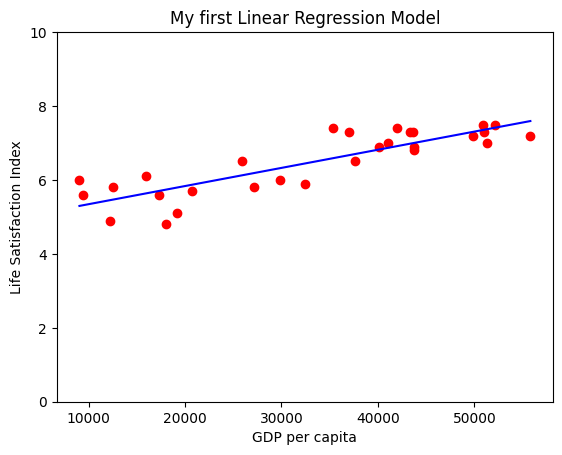

In [ ]:
# Gráfica final con el modelo entrenado

plt.scatter(X, y, color='red')
plt.xlabel("GDP per capita")
plt.ylabel("Life Satisfaction Index")
plt.title("My first Linear Regression Model")
plt.ylim(0, 10)
plt.plot(X, model.predict(X), color='blue')
